# import libraries

In [ ]:
import requests
import pandas as pd
import numpy as np
import pytz
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error

from datetime import datetime, timedelta

# CONFIG

In [ ]:
API_KEY = '2d49187691fbc44199f3ede4fcb67348'
BASE_URL = 'https://api.openweathermap.org/data/2.5/'

# FETCH WEATHER

In [ ]:
def get_current_weather(city):
    url = f"{BASE_URL}weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    if response.status_code != 200:
        print("Error:", data.get("message", "API error"))
        return None

    return {
        'city': data.get('name', ''),
        'current_temp': round(data['main'].get('temp', 0)),
        'feels_like': round(data['main'].get('feels_like', 0)),
        'temp_min': round(data['main'].get('temp_min', 0)),
        'temp_max': round(data['main'].get('temp_max', 0)),
        'humidity': round(data['main'].get('humidity', 0)),
        'description': data['weather'][0].get('description', ''),
        'country': data['sys'].get('country', ''),
        'wind_gust_dir': data['wind'].get('deg', 0),
        'pressure': data['main'].get('pressure', 0),
        'wind_gust_speed': data['wind'].get('speed', 0)
    }

# READ DATA

In [ ]:
def read_historical_data(filename):
    df = pd.read_csv(filename)
    df = df.dropna()
    df = df.drop_duplicates()
    return df

# PREPARE DATA

In [ ]:
def prepare_data(data):
    le = LabelEncoder()

    data['WindGustDir'] = le.fit_transform(data['WindGustDir'])
    data['RainTomorrow'] = le.fit_transform(data['RainTomorrow'])

    X = data[['MinTemp', 'MaxTemp', 'WindGustDir',
              'WindGustSpeed', 'Humidity', 'Pressure', 'Temp']]
    y = data['RainTomorrow']

    return X, y, le

# MODEL

In [20]:
def train_rain_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print("  Model Accuracy:", round(accuracy * 100, 2), "%")

    return model

# REGRESSION

In [21]:
def prepare_regression_data(data, feature):
    X, y = [], []

    for i in range(len(data) - 1):
        X.append(data[feature].iloc[i])
        y.append(data[feature].iloc[i + 1])

    return np.array(X).reshape(-1, 1), np.array(y)


def train_regression_model(X, y):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model


def predict_future(model, current_value):
    predictions = [current_value]

    for _ in range(5):
        next_val = model.predict(np.array([[predictions[-1]]]))
        predictions.append(next_val[0])

    return predictions[1:]

# WIND DIRECTION

In [22]:
def get_compass_direction(deg):
    compass_points = [
        ("N", 348.75, 360), ("N", 0, 11.25),
        ("NNE", 11.25, 33.75), ("NE", 33.75, 56.25),
        ("ENE", 56.25, 78.75), ("E", 78.75, 101.25),
        ("ESE", 101.25, 123.75), ("SE", 123.75, 146.25),
        ("SSE", 146.25, 168.75), ("S", 168.75, 191.25),
        ("SSW", 191.25, 213.75), ("SW", 213.75, 236.25),
        ("WSW", 236.25, 258.75), ("W", 258.75, 281.25),
        ("WNW", 281.25, 303.75), ("NW", 303.75, 326.25),
        ("NNW", 326.25, 348.75)
    ]

    for point, start, end in compass_points:
        if start <= deg < end:
            return point
    return "N"

# MAIN

In [23]:
def weather_view():

    city = input("Enter city name: ")

    current_weather = get_current_weather(city)
    if current_weather is None:
        return

    historical_data = read_historical_data('/content/weather (2).csv')

    X, y, le = prepare_data(historical_data)
    rain_model = train_rain_model(X, y)

    # Wind direction
    wind_deg = current_weather['wind_gust_dir'] % 360
    compass_dir = get_compass_direction(wind_deg)

    compass_encoded = le.transform(
        [compass_dir])[0] if compass_dir in le.classes_ else 0

    # Current input
    current_data = {
        'MinTemp': current_weather['temp_min'],
        'MaxTemp': current_weather['temp_max'],
        'WindGustDir': compass_encoded,
        'WindGustSpeed': current_weather['wind_gust_speed'],
        'Humidity': current_weather['humidity'],
        'Pressure': current_weather['pressure'],
        'Temp': current_weather['current_temp']
    }

    current_df = pd.DataFrame([current_data])

    # Rain prediction
    rain_prediction = rain_model.predict(current_df)[0]

    # Regression models
    X_temp, y_temp = prepare_regression_data(historical_data, 'Temp')
    X_hum, y_hum = prepare_regression_data(historical_data, 'Humidity')

    temp_model = train_regression_model(X_temp, y_temp)
    hum_model = train_regression_model(X_hum, y_hum)

    future_temp = predict_future(temp_model, current_weather['current_temp'])
    future_humidity = predict_future(hum_model, current_weather['humidity'])

    # Time
    timezone = pytz.timezone('Australia/Sydney')
    now = datetime.now(timezone)

    next_hour = now + timedelta(hours=1)
    next_hour = next_hour.replace(minute=0, second=0, microsecond=0)

    future_times = [(next_hour + timedelta(hours=i)).strftime("%H:00")
                    for i in range(5)]

    # ================= OUTPUT =================
    print("\n===== WEATHER REPORT =====")
    print(f"City: {city}, {current_weather['country']}")
    print(f"Temperature: {current_weather['current_temp']}°C")
    print(f"Feels Like: {current_weather['feels_like']}°C")
    print(f"Humidity: {current_weather['humidity']}%")
    print(f"Condition: {current_weather['description']}")
    print(f"Rain Tomorrow: {'Yes' if rain_prediction else 'No'}")

    print("\nFuture Temperature:")
    for t, temp in zip(future_times, future_temp):
        print(f"{t}: {round(temp,1)}°C")

    print("\nFuture Humidity:")
    for t, hum in zip(future_times, future_humidity):
        print(f"{t}: {round(hum,1)}%")

    # ================= GRAPH =================
    plt.figure()

    plt.plot(future_times, future_temp, marker='o', label='Temperature (°C)')
    plt.plot(future_times, future_humidity, marker='o', label='Humidity (%)')

    plt.title("Weather Forecast (Next 5 Hours)")
    plt.xlabel("Time")
    plt.ylabel("Values")
    plt.legend()
    plt.grid()

    plt.show()


Enter city name: brisbane
  Model Accuracy: 84.93 %

===== WEATHER REPORT =====
City: brisbane, AU
Temperature: 27°C
Feels Like: 26°C
Humidity: 22%
Condition: overcast clouds
Rain Tomorrow: No

Future Temperature:
18:00: 28.1°C
19:00: 25.1°C
20:00: 20.1°C
21:00: 16.6°C
22:00: 14.4°C

Future Humidity:
18:00: 35.1%
19:00: 38.4%
20:00: 52.3%
21:00: 43.4%
22:00: 46.8%


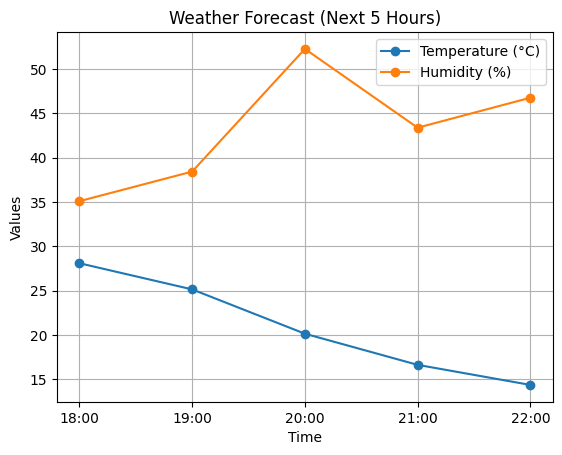

In [24]:
weather_view()

Enter city name: brisbane
🌧 Rain Model Accuracy: 84.93 %

===== WEATHER REPORT =====
City: brisbane, AU
Temperature: 27°C
Feels Like: 26°C
Humidity: 22%
Condition: overcast clouds
Rain Tomorrow: No

Future Temperature:
12:00: 28.1°C
13:00: 25.1°C
14:00: 20.1°C
15:00: 16.6°C
16:00: 14.4°C

Future Humidity:
12:00: 35.1%
13:00: 38.4%
14:00: 52.3%
15:00: 43.4%
16:00: 46.8%


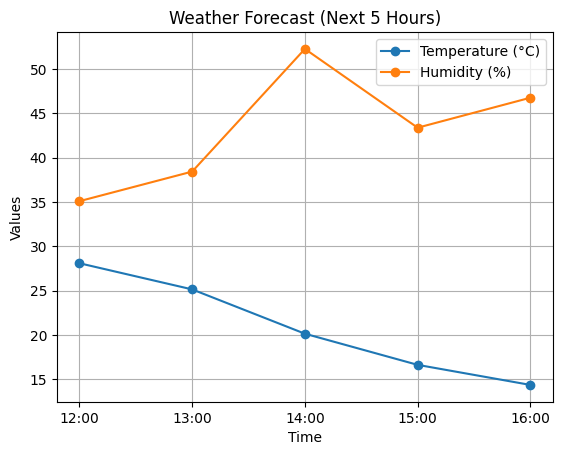

In [ ]:
import requests
import pandas as pd
import numpy as np
import pytz
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score

from datetime import datetime, timedelta

API_KEY = '2d49187691fbc44199f3ede4fcb67348'
BASE_URL = 'https://api.openweathermap.org/data/2.5/'


# ================= CONFIG =================



# ================= FETCH WEATHER =================
def get_current_weather(city):
    url = f"{BASE_URL}weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    if response.status_code != 200:
        print("Error:", data.get("message", "API error"))
        return None

    return {
        'city': data.get('name', ''),
        'current_temp': round(data['main'].get('temp', 0)),
        'feels_like': round(data['main'].get('feels_like', 0)),
        'temp_min': round(data['main'].get('temp_min', 0)),
        'temp_max': round(data['main'].get('temp_max', 0)),
        'humidity': round(data['main'].get('humidity', 0)),
        'description': data['weather'][0].get('description', ''),
        'country': data['sys'].get('country', ''),
        'wind_gust_dir': data['wind'].get('deg', 0),
        'pressure': data['main'].get('pressure', 0),
        'wind_gust_speed': data['wind'].get('speed', 0)
    }


# ================= READ DATA =================
def read_historical_data(filename):
    df = pd.read_csv(filename)
    df = df.dropna()
    df = df.drop_duplicates()
    return df


# ================= PREPARE DATA =================
def prepare_data(data):
    le = LabelEncoder()

    data['WindGustDir'] = le.fit_transform(data['WindGustDir'])
    data['RainTomorrow'] = le.fit_transform(data['RainTomorrow'])

    X = data[['MinTemp', 'MaxTemp', 'WindGustDir',
              'WindGustSpeed', 'Humidity', 'Pressure', 'Temp']]
    y = data['RainTomorrow']

    return X, y, le


# ================= RAIN MODEL =================
def train_rain_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print("🌧 Rain Model Accuracy:", round(accuracy * 100, 2), "%")

    return model


# ================= REGRESSION =================
def prepare_regression_data(data, feature):
    X, y = [], []

    for i in range(len(data) - 1):
        X.append(data[feature].iloc[i])
        y.append(data[feature].iloc[i + 1])

    return np.array(X).reshape(-1, 1), np.array(y)


def train_regression_model(X, y):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model


def predict_future(model, current_value):
    predictions = [current_value]

    for _ in range(5):
        next_val = model.predict(np.array([[predictions[-1]]]))
        predictions.append(next_val[0])

    return predictions[1:]


# ================= WIND DIRECTION =================
def get_compass_direction(deg):
    compass_points = [
        ("N", 348.75, 360), ("N", 0, 11.25),
        ("NNE", 11.25, 33.75), ("NE", 33.75, 56.25),
        ("ENE", 56.25, 78.75), ("E", 78.75, 101.25),
        ("ESE", 101.25, 123.75), ("SE", 123.75, 146.25),
        ("SSE", 146.25, 168.75), ("S", 168.75, 191.25),
        ("SSW", 191.25, 213.75), ("SW", 213.75, 236.25),
        ("WSW", 236.25, 258.75), ("W", 258.75, 281.25),
        ("WNW", 281.25, 303.75), ("NW", 303.75, 326.25),
        ("NNW", 326.25, 348.75)
    ]

    for point, start, end in compass_points:
        if start <= deg < end:
            return point
    return "N"


# ================= MAIN =================
def weather_view():

    city = input("Enter city name: ")

    current_weather = get_current_weather(city)
    if current_weather is None:
        return

    historical_data = read_historical_data('/content/weather (2).csv')

    X, y, le = prepare_data(historical_data)
    rain_model = train_rain_model(X, y)

    # Wind direction
    wind_deg = current_weather['wind_gust_dir'] % 360
    compass_dir = get_compass_direction(wind_deg)

    compass_encoded = le.transform(
        [compass_dir])[0] if compass_dir in le.classes_ else 0

    # Current input
    current_data = {
        'MinTemp': current_weather['temp_min'],
        'MaxTemp': current_weather['temp_max'],
        'WindGustDir': compass_encoded,
        'WindGustSpeed': current_weather['wind_gust_speed'],
        'Humidity': current_weather['humidity'],
        'Pressure': current_weather['pressure'],
        'Temp': current_weather['current_temp']
    }

    current_df = pd.DataFrame([current_data])

    # Rain prediction
    rain_prediction = rain_model.predict(current_df)[0]

    # Regression models
    X_temp, y_temp = prepare_regression_data(historical_data, 'Temp')
    X_hum, y_hum = prepare_regression_data(historical_data, 'Humidity')

    temp_model = train_regression_model(X_temp, y_temp)
    hum_model = train_regression_model(X_hum, y_hum)

    future_temp = predict_future(temp_model, current_weather['current_temp'])
    future_humidity = predict_future(hum_model, current_weather['humidity'])

    # Time
    timezone = pytz.timezone('Asia/Kolkata')
    now = datetime.now(timezone)

    next_hour = now + timedelta(hours=1)
    next_hour = next_hour.replace(minute=0, second=0, microsecond=0)

    future_times = [(next_hour + timedelta(hours=i)).strftime("%H:00")
                    for i in range(5)]

    # ================= OUTPUT =================
    print("\n===== WEATHER REPORT =====")
    print(f"City: {city}, {current_weather['country']}")
    print(f"Temperature: {current_weather['current_temp']}°C")
    print(f"Feels Like: {current_weather['feels_like']}°C")
    print(f"Humidity: {current_weather['humidity']}%")
    print(f"Condition: {current_weather['description']}")
    print(f"Rain Tomorrow: {'Yes' if rain_prediction else 'No'}")

    print("\nFuture Temperature:")
    for t, temp in zip(future_times, future_temp):
        print(f"{t}: {round(temp,1)}°C")

    print("\nFuture Humidity:")
    for t, hum in zip(future_times, future_humidity):
        print(f"{t}: {round(hum,1)}%")

    # ================= GRAPH =================
    plt.figure()

    plt.plot(future_times, future_temp, marker='o', label='Temperature (°C)')
    plt.plot(future_times, future_humidity, marker='o', label='Humidity (%)')

    plt.title("Weather Forecast (Next 5 Hours)")
    plt.xlabel("Time")
    plt.ylabel("Values")
    plt.legend()
    plt.grid()

    plt.show()


# ================= RUN =================
weather_view()